In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os


loading the 6 datasets which includes the crisis and the corresponding total coverage received over the mentioned crisis days , the table also includes coverage quantitatively calculated per day,per required_funding,per people_effected

In [4]:
csv_dir = "../../data/raw/"  

crises_df = pd.read_csv(os.path.join(csv_dir, "chart1_overall_coverage_bar.csv"))
monthly_df = pd.read_csv(os.path.join(csv_dir, "chart3_monthly_coverage.csv"))
outlet_df = pd.read_csv(os.path.join(csv_dir, "chart4_crisis_coverage_per_outlet_chart.csv"))
framing_df = pd.read_csv(os.path.join(csv_dir, "framing_per_article.csv"))
sentiment_df = pd.read_csv(os.path.join(csv_dir, "sentiment_per_article.csv"))
victim_df = pd.read_csv(os.path.join(csv_dir, "victim_causor_per_article.csv"))

Displaying first five rows of all tables

In [5]:
from IPython.display import display, Markdown

tables = [crises_df, monthly_df, outlet_df, framing_df, sentiment_df, victim_df]
names = ['Crises', 'Monthly Coverage', 'Coverage by Outlet', 'Framing', 'Sentiment', 'Victim/Causor']

for name, df in zip(names, tables):
    display(Markdown(f"### {name} Table (First 5 Rows)"))
    display(df.head())

### Crises Table (First 5 Rows)

,crisis_name,raw_coverage,start_date,fund_required,people_affected,crisis_days,coverage_per_day,coverage_per_funding,coverage_per_people
0,Afghanistan,8302,8/1/2021,3.04,22.9,1287,6.450660,2730.921053,362.532751
1,Chad,349,7/1/2009,1.50,7.8,5701,0.061217,232.666667,44.743590
2,Democratic Republic of the Congo,1580,3/1/2022,3.23,21.2,1075,1.469767,489.164087,74.528302
3,Ethiopia,1511,11/1/2020,2.00,10.0,1560,0.968590,755.500000,151.100000
4,Gaza and the Occupied Palestinian Territories,29020,10/1/2023,4.00,3.3,496,58.508065,7255.000000,8793.939394


### Monthly Coverage Table (First 5 Rows)

,crisis_name,year_month,coverage_count
0,Afghanistan,2021-08,3306
1,Afghanistan,2021-09,981
2,Afghanistan,2021-10,305
3,Afghanistan,2021-11,212
4,Afghanistan,2021-12,156


### Coverage by Outlet Table (First 5 Rows)

...

,crisis_name,framing,raw_count,article_count,mentions_per_article,outlet
0,Gaza and the Occupied Palestinian Territories,economic,4,408,0.009804,USA Today
1,Gaza and the Occupied Palestinian Territories,geopolitical,109,408,0.267157,USA Today
2,Gaza and the Occupied Palestinian Territories,humanitarian,151,408,0.370098,USA Today
3,Gaza and the Occupied Palestinian Territories,legal,11,408,0.026961,USA Today
4,Gaza and the Occupied Palestinian Territories,military,74,408,0.181373,USA Today


### Sentiment Table (First 5 Rows)

,entity,sentiment,crisis_name,mentions_per_article,raw_count,outlet
0,Putin,negative,Ukraine,0.410853,106,USA Today
1,Putin,neutral,Ukraine,0.050388,13,USA Today
2,Putin,positive,Ukraine,0.003876,1,USA Today
3,Zelensky,positive,Ukraine,0.213178,55,USA Today
4,Zelensky,neutral,Ukraine,0.077519,20,USA Today


### Victim/Causor Table (First 5 Rows)

,group,framing_type,crisis_name,mentions_per_article,raw_count,outlet
0,Russia,victim,Ukraine,0.015504,4,USA Today
1,Russia,causor,Ukraine,0.736434,190,USA Today
2,Ukraine,victim,Ukraine,0.678295,175,USA Today
3,Ukraine,causor,Ukraine,0.000000,0,USA Today
4,Israel,victim,Gaza and the Occupied Palestinian Territories,0.536765,219,USA Today


Checking Shape and dtypes for every table

In [6]:
# List of tables and their names
tables = [crises_df, monthly_df, outlet_df, framing_df, sentiment_df, victim_df]
names = ['Crises', 'Monthly Coverage', 'Coverage by Outlet', 'Framing', 'Sentiment', 'Victim/Causor']

print("=== Table Shape & Column Types ===\n")

for name, df in zip(names, tables):
    print(f"--- {name} Table ---")
    print("Shape:", df.shape)
    print("Columns & dtypes:")
    display(df.dtypes)  # nicely formatted in Jupyter
    print("\n")  # blank line for spacing

=== Table Shape & Column Types ===

--- Crises Table ---
Shape: (10, 9)
Columns & dtypes:


crisis_name              object
raw_coverage              int64
start_date               object
fund_required           float64
people_affected         float64
crisis_days               int64
coverage_per_day        float64
coverage_per_funding    float64
coverage_per_people     float64
dtype: object



--- Monthly Coverage Table ---
Shape: (734, 3)
Columns & dtypes:


crisis_name       object
year_month        object
coverage_count     int64
dtype: object



--- Coverage by Outlet Table ---
Shape: (403, 10)
Columns & dtypes:


...

crisis_name              object
framing                  object
raw_count                 int64
article_count             int64
mentions_per_article    float64
outlet                   object
dtype: object



--- Sentiment Table ---
Shape: (430, 6)
Columns & dtypes:


entity                   object
sentiment                object
crisis_name              object
mentions_per_article    float64
raw_count                 int64
outlet                   object
dtype: object



--- Victim/Causor Table ---
Shape: (348, 6)
Columns & dtypes:


group                    object
framing_type             object
crisis_name              object
mentions_per_article    float64
raw_count                 int64
outlet                   object
dtype: object

Checking Missing values

In [7]:
tables = [crises_df, monthly_df, outlet_df, framing_df, sentiment_df, victim_df]
names = ['Crises', 'Monthly Coverage', 'Coverage by Outlet', 'Framing', 'Sentiment', 'Victim/Causor']

print("=== Missing Values Summary for Each Table ===\n")

for name, df in zip(names, tables):
    print(f"--- {name} Table ---")
    missing_counts = df.isnull().sum()
    total_rows = len(df)
    # Show missing values and percentage
    missing_percent = (missing_counts / total_rows * 100).round(2)
    missing_summary = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_percent})
    display(missing_summary) 
    print("\n")

=== Missing Values Summary for Each Table ===

--- Crises Table ---


,Missing Count,Missing %
crisis_name,0,0.0
raw_coverage,0,0.0
start_date,0,0.0
fund_required,0,0.0
people_affected,0,0.0
crisis_days,0,0.0
coverage_per_day,0,0.0
coverage_per_funding,0,0.0
coverage_per_people,0,0.0




--- Monthly Coverage Table ---


,Missing Count,Missing %
crisis_name,0,0.0
year_month,0,0.0
coverage_count,0,0.0




--- Coverage by Outlet Table ---


...

,Missing Count,Missing %
crisis_name,0,0.0
framing,0,0.0
raw_count,0,0.0
article_count,0,0.0
mentions_per_article,0,0.0
outlet,0,0.0




--- Sentiment Table ---


,Missing Count,Missing %
entity,0,0.0
sentiment,0,0.0
crisis_name,0,0.0
mentions_per_article,0,0.0
raw_count,0,0.0
outlet,0,0.0




--- Victim/Causor Table ---


,Missing Count,Missing %
group,0,0.0
framing_type,0,0.0
crisis_name,0,0.0
mentions_per_article,0,0.0
raw_count,0,0.0
outlet,0,0.0


Summary statistics for numeric columns

In [8]:
# Simple descriptive statistics visualization for numeric columns
tables = [crises_df, monthly_df, outlet_df]
names = ['Crises', 'Monthly Coverage', 'Coverage by Outlet']

for name, df in zip(names, tables):
    print(f"--- {name} Table ---")
    
    numeric_cols = df.select_dtypes(include=np.number).columns
    print("Numeric columns:", list(numeric_cols))
    display(df[numeric_cols].describe())

--- Crises Table ---
Numeric columns: ['raw_coverage', 'fund_required', 'people_affected', 'crisis_days', 'coverage_per_day', 'coverage_per_funding', 'coverage_per_people']


,raw_coverage,fund_required,people_affected,crisis_days,coverage_per_day,coverage_per_funding,coverage_per_people
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,7832.200000,3.955000,16.440000,2355.500000,9.273478,2179.636337,1199.826921
std,9909.340081,3.041956,8.051528,1891.970769,18.249530,2585.448501,2715.593966
min,349.000000,1.100000,3.300000,496.000000,0.061217,170.136187,44.743590
25%,1622.250000,2.125000,10.675000,1082.000000,0.748698,555.748065,79.212809
50%,1914.500000,3.135000,18.100000,1423.500000,1.769834,1008.935664,126.139744
75%,9982.000000,3.830000,20.875000,3546.750000,5.481957,2470.008971,564.076302
max,29020.000000,10.280000,30.400000,5701.000000,58.508065,7255.000000,8793.939394


--- Monthly Coverage Table ---
Numeric columns: ['coverage_count']


,coverage_count
count,734.000000
mean,106.705722
std,440.070375
min,1.000000
25%,7.000000
50%,22.000000
75%,50.000000
max,7299.000000


--- Coverage by Outlet Table ---
Numeric columns: ['coverage_count', 'fund_required', 'people_affected', 'crisis_days', 'coverage_per_day', 'coverage_per_funding', 'coverage_per_people']


,coverage_count,fund_required,people_affected,crisis_days,coverage_per_day,coverage_per_funding,coverage_per_people
count,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000
mean,194.347395,4.068958,16.542184,2262.573201,0.230111,54.085269,29.772380
std,328.177909,2.881350,7.661038,1755.442901,0.541285,89.008366,79.118722
min,1.000000,1.100000,3.300000,496.000000,0.000175,0.097276,0.032895
25%,9.000000,2.000000,10.000000,1075.000000,0.004510,3.405573,0.518868
50%,37.000000,3.230000,19.500000,1287.000000,0.023256,12.048193,2.200000
75%,219.000000,4.000000,21.200000,3813.000000,0.132731,64.900000,15.917031
max,1917.000000,10.280000,30.400000,5701.000000,3.864919,525.602410,580.909091


Assign crisis_id to the data frames

In [9]:
crises_df = crises_df.reset_index().rename(columns={"index":"crisis_id"})
crises_df["crisis_id"] = crises_df["crisis_id"] + 1  # Start IDs at 1
crises_df.head()

,crisis_id,crisis_name,raw_coverage,start_date,fund_required,people_affected,crisis_days,coverage_per_day,coverage_per_funding,coverage_per_people
0,1,Afghanistan,8302,8/1/2021,3.04,22.9,1287,6.450660,2730.921053,362.532751
1,2,Chad,349,7/1/2009,1.50,7.8,5701,0.061217,232.666667,44.743590
2,3,Democratic Republic of the Congo,1580,3/1/2022,3.23,21.2,1075,1.469767,489.164087,74.528302
3,4,Ethiopia,1511,11/1/2020,2.00,10.0,1560,0.968590,755.500000,151.100000
4,5,Gaza and the Occupied Palestinian Territories,29020,10/1/2023,4.00,3.3,496,58.508065,7255.000000,8793.939394


Create a mapping: crisis_name -> crisis_id

In [10]:

crises_map = dict(zip(crises_df["crisis_name"], crises_df["crisis_id"]))

Adding crisis_id to child tables

In [11]:
monthly_df["crisis_id"] = monthly_df["crisis_name"].map(crises_map)
outlet_df["crisis_id"] = outlet_df["crisis_name"].map(crises_map)
framing_df["crisis_id"] = framing_df["crisis_name"].map(crises_map)
sentiment_df["crisis_id"] = sentiment_df["crisis_name"].map(crises_map)
victim_df["crisis_id"] = victim_df["crisis_name"].map(crises_map)

Create a SQLite DB

In [12]:
db_file = "humanitarian.db"
conn = sqlite3.connect(db_file)
cursor = conn.cursor()


To Run schema.sql

In [13]:
with open("../sql/schema.sql", "r") as f:
    cursor.executescript(f.read())

FileNotFoundError: [Errno 2] No such file or directory: '../sql/schema.sql'

populating tables:

## Crises table
Descriptions of each crisis

In [ ]:
crises_df[['crisis_id','crisis_name','start_date','fund_required','people_affected','crisis_days',
           'raw_coverage','coverage_per_day','coverage_per_funding','coverage_per_people']].to_sql(
    "crises", conn, if_exists="append", index=False)

10

In [ ]:
crises_df.head()

,crisis_id,crisis_name,raw_coverage,start_date,fund_required,people_affected,crisis_days,coverage_per_day,coverage_per_funding,coverage_per_people
0,1,Afghanistan,8302,8/1/2021,3.04,22.9,1287,6.450660,2730.921053,362.532751
1,2,Chad,349,7/1/2009,1.50,7.8,5701,0.061217,232.666667,44.743590
2,3,Democratic Republic of the Congo,1580,3/1/2022,3.23,21.2,1075,1.469767,489.164087,74.528302
3,4,Ethiopia,1511,11/1/2020,2.00,10.0,1560,0.968590,755.500000,151.100000
4,5,Gaza and the Occupied Palestinian Territories,29020,10/1/2023,4.00,3.3,496,58.508065,7255.000000,8793.939394


## Monthly coverage table
Monthly coverage of each crisis

In [ ]:
monthly_clean = monthly_df[['crisis_id', 'year_month', 'coverage_count']]

monthly_clean.to_sql(
    "monthly_coverage",
    conn,
    if_exists="append",
    index=False
)


734

In [ ]:
monthly_clean.head()

,crisis_id,year_month,coverage_count
0,1,2021-08,3306
1,1,2021-09,981
2,1,2021-10,305
3,1,2021-11,212
4,1,2021-12,156


## Coverage by outlet table
Coverage of crisis by each outlet

In [ ]:
outlet_clean = outlet_df[['crisis_id','matched_outlet',
                          'coverage_count','coverage_per_day',
                          'coverage_per_funding','coverage_per_people']]

outlet_clean = outlet_clean.rename(columns={'matched_outlet':'outlet_name'})

outlet_clean.to_sql("coverage_by_outlet", conn, if_exists="append", index=False)


403

In [ ]:
outlet_clean.head()

,crisis_id,outlet_name,coverage_count,coverage_per_day,coverage_per_funding,coverage_per_people
0,1,ABC News,432,0.335664,142.105263,18.864629
1,1,AP News,291,0.226107,95.723684,12.707424
2,1,Al Jazeera,528,0.410256,173.684211,23.056769
3,1,BBC,562,0.436674,184.868421,24.541485
4,1,Birmigham Live,5,0.003885,1.644737,0.218341


## Framing Table 
Framing type of article and respective counts 

In [ ]:
framing_clean = framing_df[['crisis_id','outlet',
                            'framing','raw_count',
                            'article_count','mentions_per_article']]

framing_clean = framing_clean.rename(columns={
    'outlet':'outlet_name',
    'framing':'framing_type'
})

framing_clean.to_sql("framing", conn, if_exists="append", index=False)


471

In [ ]:
framing_clean.head()

,crisis_id,outlet_name,framing_type,raw_count,article_count,mentions_per_article
0,5,USA Today,economic,4,408,0.009804
1,5,USA Today,geopolitical,109,408,0.267157
2,5,USA Today,humanitarian,151,408,0.370098
3,5,USA Today,legal,11,408,0.026961
4,5,USA Today,military,74,408,0.181373


## Sentiment table
Sentiment about how a related political entitiy/ famous personality is potryed in the article and respective count of mentions per article.

In [ ]:
sentiment_clean = sentiment_df[['crisis_id','outlet',
                                'entity','sentiment',
                                'raw_count','mentions_per_article']]

sentiment_clean = sentiment_clean.rename(columns={'outlet':'outlet_name'})

sentiment_clean.to_sql("sentiment", conn, if_exists="append", index=False)


430

In [ ]:
sentiment_clean.head()

,crisis_id,outlet_name,entity,sentiment,raw_count,mentions_per_article
0,9,USA Today,Putin,negative,106,0.410853
1,9,USA Today,Putin,neutral,13,0.050388
2,9,USA Today,Putin,positive,1,0.003876
3,9,USA Today,Zelensky,positive,55,0.213178
4,9,USA Today,Zelensky,neutral,20,0.077519


## victim_causor table
The victim_causor table captures how different actors involved in a crisis are framed in media coverage.
Groups are portrayed as victims or causors.

In [ ]:
victim_clean = victim_df[['crisis_id','outlet',
                          'group','framing_type',
                          'raw_count','mentions_per_article']]

victim_clean = victim_clean.rename(columns={'outlet':'outlet_name'})

victim_clean.to_sql("victim_causor", conn, if_exists="append", index=False)

348

In [ ]:
victim_clean.head()

,crisis_id,outlet_name,group,framing_type,raw_count,mentions_per_article
0,9,USA Today,Russia,victim,4,0.015504
1,9,USA Today,Russia,causor,190,0.736434
2,9,USA Today,Ukraine,victim,175,0.678295
3,9,USA Today,Ukraine,causor,0,0.000000
4,5,USA Today,Israel,victim,219,0.536765


created a schema diagram using dbdiagram.io and is attached as .PNG in Docs/

## Data Exploration

### Total Media Coverage per Crisis

This bar plot shows the total number of articles published for each crisis across all media outlets in the dataset. 
It helps us understand which humanitarian crises received the most media attention overall.

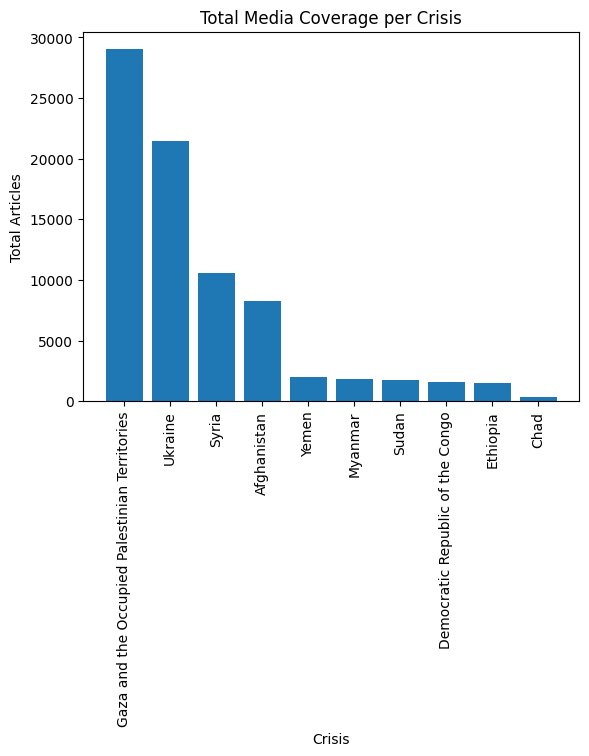

In [ ]:
top_crisis = crises_df.sort_values('raw_coverage', ascending=False)

plt.figure()
plt.bar(top_crisis['crisis_name'], top_crisis['raw_coverage'])
plt.xticks(rotation=90)
plt.title("Total Media Coverage per Crisis")
plt.xlabel("Crisis")
plt.ylabel("Total Articles")
plt.show()


**Observations:**

- Gaza received the highest total media coverage by a significant margin, despite being a more recent crisis.
- Ukraine ranks second, noticeably behind Gaza but ahead of other crises.
- Syria comes third, followed by Afghanistan.
- Chad received the least media coverage, much lower than all others.
- Crises ranked fifth to ninth (Yemen to Ethiopia) have similar coverage numbers, indicating roughly comparable media attention among these mid-to-last-ranked crises.

### Monthly Media Coverage Trends for Top 5 Crises

To better understand how media attention evolves over time, we visualize the monthly coverage trends for the five crises with the highest total media coverage. 

Each line represents a crisis and shows the number of articles published in each month. This helps reveal patterns such as sudden spikes in coverage, sustained media attention, or declining interest over time. 

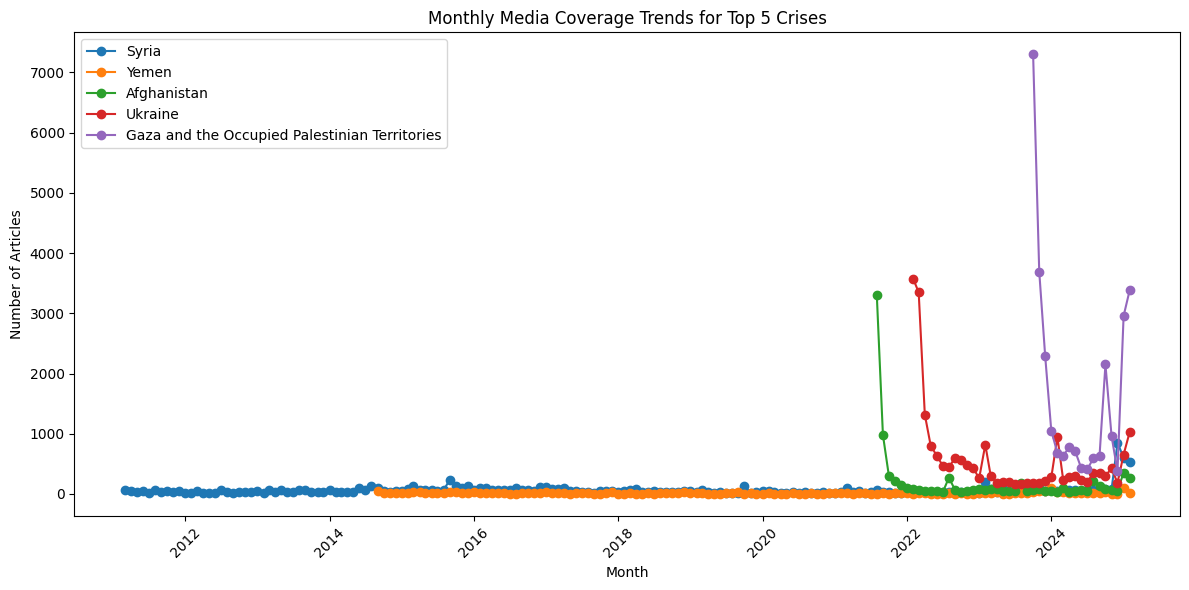

In [ ]:
# Get top 5 crises by total coverage
top5_crises = crises_df.sort_values('raw_coverage', ascending=False).head(5)

top5_ids = top5_crises['crisis_id']

# Filter monthly data
monthly_top5 = monthly_df[monthly_df['crisis_id'].isin(top5_ids)]

# Sort months for clean plotting
monthly_top5 = monthly_top5.sort_values('year_month')
monthly_top5['year_month'] = pd.to_datetime(monthly_top5['year_month'])

# Plot
plt.figure(figsize=(12,6))

for crisis in monthly_top5['crisis_name'].unique():
    subset = monthly_top5[monthly_top5['crisis_name'] == crisis]
    plt.plot(subset['year_month'], subset['coverage_count'], marker='o', label=crisis)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.title("Monthly Media Coverage Trends for Top 5 Crises")
plt.legend()
plt.tight_layout()
plt.show()


**Observations:**

- Syria has the longest coverage period, starting in 2011 and continuing through 2025, with steady low article counts over time. Some spikes occur recently.
- Yemen started around late 2014 and has a similar long-term trend.
- Afghanistan began in 2022, with an initial spike around 3,500 articles, followed by a rapid decline and then stable low coverage.
- Ukraine also started in 2022, initially with slightly higher articles than Afghanistan, and fluctuates more and remains consistently above Afghanistan after the initial decline.
- Gaza, despite being the most recent crisis (2024), has the highest number of articles, initially above 7,000, suggesting recent media activity is higher, potentially due to contemporary reporting trends.

### Coverage by Media Outlet

This horizontal bar plot displays total article counts across all crises by each media outlet.  
It highlights which outlets contributed the most coverage in the dataset.

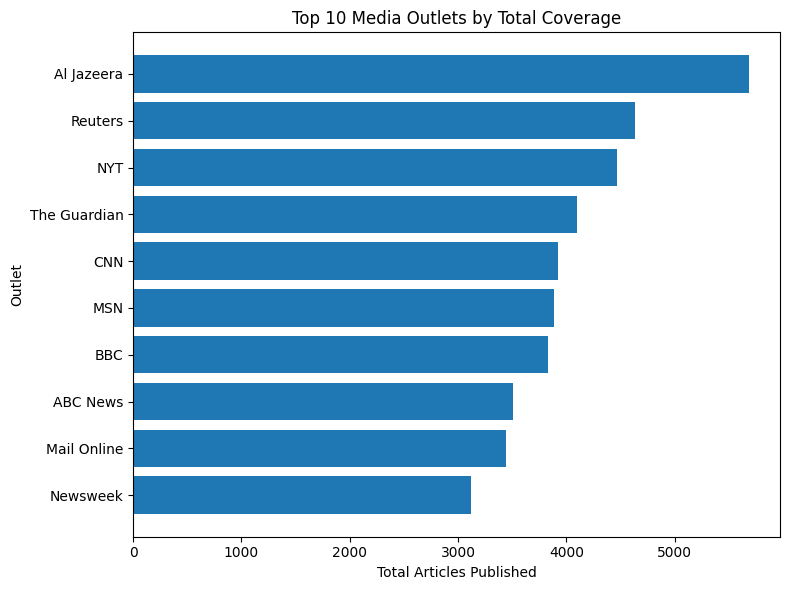

In [ ]:
# Aggregate coverage by outlet across all crises
outlet_grouped = outlet_df.groupby('matched_outlet')['coverage_count'].sum().sort_values(ascending=False).head(10)

# Plot top 10 outlets
plt.figure(figsize=(8,6))
plt.barh(outlet_grouped.index[::-1], outlet_grouped.values[::-1])  # reverse for largest on top
plt.xlabel("Total Articles Published")
plt.ylabel("Outlet")
plt.title("Top 10 Media Outlets by Total Coverage")
plt.tight_layout()
plt.show()

**Observations:**  

- **Al Jazeera** has the highest total coverage, significantly higher than **Reuters**.  
- **Reuters** comes second, slightly ahead of **The New York Times**, which is in third place.  
- There is a smaller gap between the third (**NYT**) and fourth-ranked outlet, while the decline from fourth place downward is relatively steady.  
- Overall, the distribution shows a gradual decline across outlets rather than a concentration only in the top few.  

### Entity-level Sentiment

This plot shows the sentiment associated with key entities mentioned in articles.  
Positive, neutral, and negative labels reflect how entities (like political leaders or groups) are portrayed, not the crises themselves.

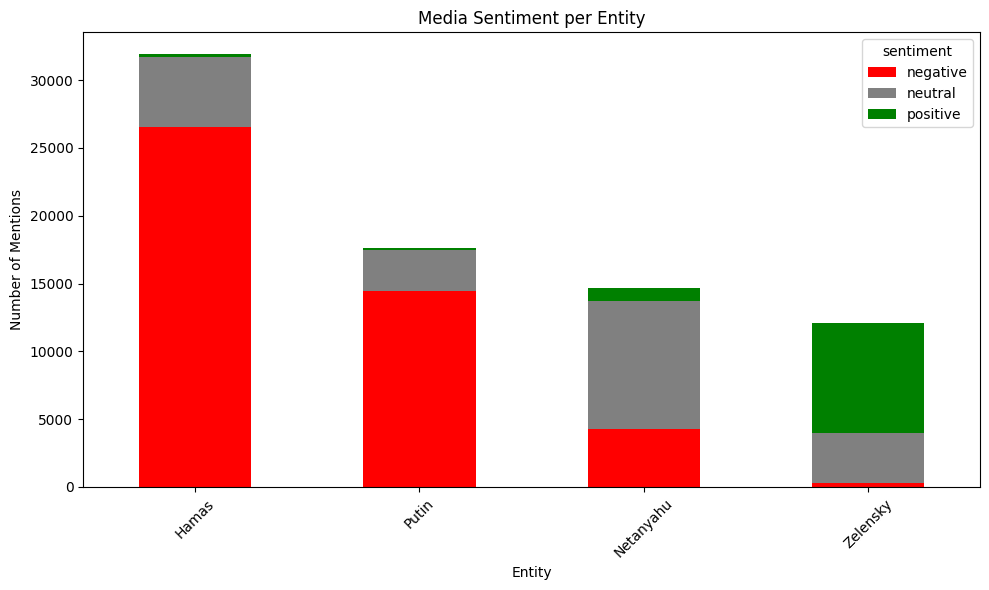

In [ ]:
# Pivot table: entities x sentiment counts
entity_sentiment = sentiment_df.pivot_table(
    index='entity',
    columns='sentiment',
    values='raw_count',
    aggfunc='sum',
    fill_value=0
)

# Sort by total mentions
entity_sentiment['total'] = entity_sentiment.sum(axis=1)
entity_sentiment = entity_sentiment.sort_values('total', ascending=False)
entity_sentiment = entity_sentiment.drop(columns='total')

# Plot stacked bar chart
entity_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color={'positive':'green','neutral':'grey','negative':'red'}
)

plt.ylabel("Number of Mentions")
plt.xlabel("Entity")
plt.title("Media Sentiment per Entity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations:**

- Hamas is associated with a predominantly negative sentiment across all articles where it appears.
- Zelensky is mostly portrayed positively.
- The sentiment distribution is limited to a few entities and a small number of crises, so overall insights are constrained.

### Framing Distribution

This bar plot shows the distribution of article framing types for crises.  
Framing categories include: humanitarian, military, geopolitical, economic, legal, and other.

C:\Users\ashri\AppData\Local\Temp\ipykernel_25792\3143643285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=framing_counts.index, y=framing_counts.values, palette='viridis')


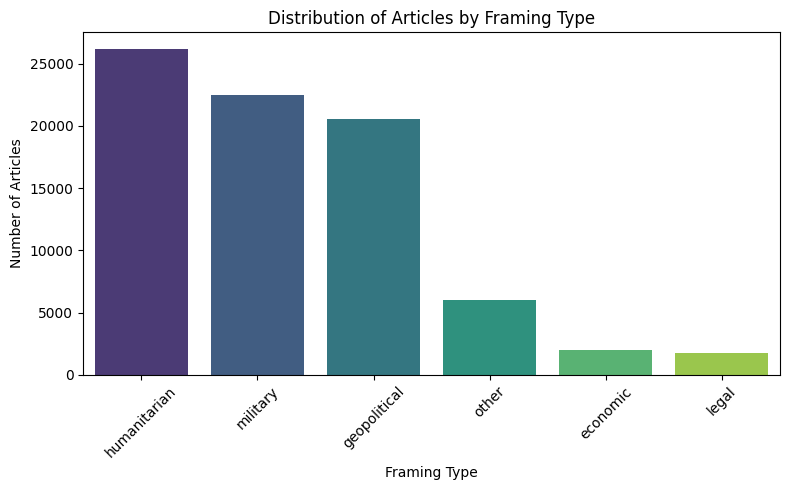

In [ ]:
# Aggregate articles per framing type
framing_counts = framing_df.groupby('framing')['raw_count'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=framing_counts.index, y=framing_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Number of Articles")
plt.xlabel("Framing Type")
plt.title("Distribution of Articles by Framing Type")
plt.tight_layout()
plt.show()

**Observations:**

- Humanitarian framing dominates the dataset, with the highest number of articles.
- Military and geopolitical framings follow but are slightly lesser common.
- Legal and Economic framing has the least and second least number of articles.
- Other occupies an intermediate position.

### Summary Table of Crises

This table summarizes key attributes for each crisis, including total media coverage, duration, fund requirements, and people affected.  
It provides a quick reference for comparing crises across multiple metrics.

In [ ]:
# Select relevant columns
summary_cols = ['crisis_name','start_date','fund_required','people_affected','crisis_days',
                'raw_coverage','coverage_per_day','coverage_per_funding','coverage_per_people']

# Create summary table
crises_summary = crises_df[summary_cols].sort_values('raw_coverage', ascending=False)

# Display table
crises_summary

,crisis_name,start_date,fund_required,people_affected,crisis_days,raw_coverage,coverage_per_day,coverage_per_funding,coverage_per_people
4,Gaza and the Occupied Palestinian Territories,10/1/2023,4.00,3.3,496,29020,58.508065,7255.000000,8793.939394
8,Ukraine,2/1/2022,3.32,12.7,1103,21440,19.437897,6457.831325,1688.188976
7,Syria,3/1/2011,8.58,16.7,5093,10542,2.069900,1228.671329,631.257485
0,Afghanistan,8/1/2021,3.04,22.9,1287,8302,6.450660,2730.921053,362.532751
9,Yemen,9/1/2014,2.50,19.5,3813,1973,0.517440,789.200000,101.179487
5,Myanmar,8/1/2017,1.10,19.9,2748,1856,0.675400,1687.272727,93.266332
6,Sudan,4/1/2023,10.28,30.4,679,1749,2.575847,170.136187,57.532895
2,Democratic Republic of the Congo,3/1/2022,3.23,21.2,1075,1580,1.469767,489.164087,74.528302
3,Ethiopia,11/1/2020,2.00,10.0,1560,1511,0.968590,755.500000,151.100000
1,Chad,7/1/2009,1.50,7.8,5701,349,0.061217,232.666667,44.743590


### intermidiate Conclusion

- Gaza and Ukraine dominate media coverage among all crises, with Gaza being particularly high despite its recent onset.  
- Long-standing crises like Syria and Yemen maintain consistent attention over time, reflecting persistent media interest.  
- Media coverage is concentrated among a few major outlets, such as Al Jazeera, Reuters, and The New York Times, followed by others.  
- Humanitarian framing is the most common across articles, while legal and economic framings are less frequent.  
- Entity-level sentiment analysis highlights contrasting perceptions of key figures: Hamas is predominantly negative, while Zelensky is predominantly positive.  

Overall, this analysis illustrates the uneven media representation of humanitarian crises, with recent, high-profile events receiving disproportionate coverage and certain entities shaping the narrative more than the crises themselves.